# Voice-Controlled Cart KWS — EI `.npy` → Train, Prune, Quantize

This notebook replaces the raw-WAV pipeline with **pre-computed Edge Impulse MFCC `.npy` exports**.
EI Studio's *Export* → *NumPy* produces four files:

```
X_train.npy   # (N_train, feature_len)  float32 MFCC features
y_train.npy   # (N_train,)              int label indices
X_test.npy    # (N_test,  feature_len)
y_test.npy    # (N_test,)               int label indices
```

The pipeline:
1. **Load** the four `.npy` files
2. **EDA** — class counts, feature distributions, sample visualisation
3. **Train** the same Conv1D architecture as the EI float32 baseline
4. **Prune** with magnitude-based polynomial decay
5. **Post-training int8 quantization**
6. **Evaluate** all three models (baseline / pruned-float / pruned-int8)

> **Note:** because EI's C++ DSP block and this Python training path now use the *same* pre-computed features, preprocessing is bit-identical — there is no mismatch between training and deployment.


In [1]:
%pip install -q tensorflow tensorflow_model_optimization scikit-learn matplotlib seaborn


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import numpy as np
import tensorflow as tf
import tensorflow_model_optimization as tfmot
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

print('TF', tf.__version__, '| tfmot', tfmot.__version__)
np.random.seed(0)
tf.random.set_seed(0)

TF 2.14.1 | tfmot 0.8.0


## 0. Config

Set `DATA_DIR` to the folder that contains your four `.npy` exports from EI Studio.
Set `CLASSES` to the **exact order** EI used when encoding your integer labels (check *Dashboard → Classes*).

In [3]:
# ── Paths ──────────────────────────────────────────────────────────────────────
# Folder containing X_train.npy, y_train.npy, X_test.npy, y_test.npy
DATA_DIR   = 'voice_MFCC'
MODELS_DIR = 'modelsMFCC'
os.makedirs(MODELS_DIR, exist_ok=True)

EI_MODEL_PATH   = 'model.h5'              # exported from EI Studio → Dashboard → Download model → Keras (.h5)

BASELINE_TFLITE = f'{MODELS_DIR}/baseline_float.tflite'
PRUNED_TFLITE   = f'{MODELS_DIR}/pruned_float.tflite'
INT8_TFLITE     = f'{MODELS_DIR}/pruned_int8.tflite'
INT8_CC         = f'{MODELS_DIR}/kws_model.cc'

# ── Class list ─────────────────────────────────────────────────────────────────
# Must match the label order EI used when it encoded y_train / y_test.
# Check EI Studio → Dashboard → Classes, or inspect np.unique(y_train) below.
# EI encodes labels as 1-based integers; the decoder below converts to 0-based.
# Must match EI's 1-based label order exactly (check EI Dashboard → Classes).
# 'unknown' is index 6 in EI → 5 after 0-basing; present in train even if absent in test.
CLASSES = ['backward', 'forward', 'left', 'right', 'stop', 'unknown']

# ── EI MFCC / model geometry ───────────────────────────────────────────────────
# These must match the values in your EI impulse's MFCC block.
# With the defaults (2 s window, 20 ms frame, 20 ms stride, 13 cepstral coeffs)
# you get 100 frames × 13 coeffs = 1300 features.
N_FRAMES    = 100
N_CEPSTRAL  = 13
FEATURE_LEN = N_FRAMES * N_CEPSTRAL   # 1300

# ── Training hyper-params ──────────────────────────────────────────────────────
BATCH_SIZE       = 32
PRUNE_EPOCHS     = 15
FINAL_SPARSITY   = 0.50
LEARNING_RATE    = 1e-3     # used only for prune fine-tuning
VAL_FRAC         = 0.15
REP_DATASET_N    = 200

print(f'Feature vector length: {FEATURE_LEN}  ({N_FRAMES} frames × {N_CEPSTRAL} coeffs)')
print(f'Classes ({len(CLASSES)}):', CLASSES)

Feature vector length: 1300  (100 frames × 13 coeffs)
Classes (6): ['backward', 'forward', 'left', 'right', 'stop', 'unknown']


## 1. Load `.npy` data

Just four `np.load` calls — no audio decoding, no feature extraction.

In [4]:
def load_ei_npy(x_path, y_path):
    """Load EI MFCC .npy export.

    EI y arrays are 2-D: (N, 4)
      col 0 : 1-based class index
      col 1 : sample timestamp (ignore)
      col 2 : window offset ms  (ignore)
      col 3 : window length ms  (ignore)
    We extract col 0 and convert to 0-based indices.
    """
    X = np.load(x_path).astype(np.float32)
    y_raw = np.load(y_path)

    if y_raw.ndim == 2:
        # EI metadata format — grab the class column and make 0-based
        y = (y_raw[:, 0] - 1).astype(np.int64)
    else:
        # Already integer indices — check if 1-based
        y = y_raw.astype(np.int64)
        if y.min() == 1:
            y = y - 1

    return X, y

X_train_full, y_train_full = load_ei_npy(
    os.path.join(DATA_DIR, 'ei-voicecontrolledcart-mfcc-X_training.14.npy'),
    os.path.join(DATA_DIR, 'ei-voicecontrolledcart-mfcc-y_training.14.npy'),
)
X_test, y_test = load_ei_npy(
    os.path.join(DATA_DIR, 'ei-voicecontrolledcart-mfcc-X_testing.14.npy'),
    os.path.join(DATA_DIR, 'ei-voicecontrolledcart-mfcc-y_testing.14.npy'),
)

# ── Basic sanity checks ────────────────────────────────────────────────────────
assert X_train_full.ndim == 2, 'X_train should be 2-D: (samples, features)'
assert X_train_full.shape[1] == FEATURE_LEN, (
    f'Expected {FEATURE_LEN} features, got {X_train_full.shape[1]}. '
    'Check N_FRAMES / N_CEPSTRAL in Config.')
assert X_train_full.shape[0] == y_train_full.shape[0], 'X/y train length mismatch'
assert X_test.shape[0]       == y_test.shape[0],       'X/y test length mismatch'
assert set(np.unique(y_test)).issubset(set(range(len(CLASSES)))), (
    f'Test labels outside CLASSES range. '
    f'Unique test indices: {np.unique(y_test).tolist()}, '
    f'expected 0–{len(CLASSES)-1}. '
    f'Check CLASSES list in Config.')

print(f'X_train_full : {X_train_full.shape}   dtype={X_train_full.dtype}')
print(f'y_train_full : {y_train_full.shape}')
print(f'X_test       : {X_test.shape}')
print(f'y_test       : {y_test.shape}')


X_train_full : (12197, 1300)   dtype=float32
y_train_full : (12197,)
X_test       : (2998, 1300)
y_test       : (2998,)


## 2. Exploratory Data Analysis (EDA)

### 2a. Class counts

In [5]:
from collections import Counter

def class_count_table(y, split_name):
    counts = Counter(y.tolist())
    total = len(y)
    print(f'\n{split_name} ({total} samples)')
    print(f'{"Class":<12} {"Count":>7}  {"Pct":>6}')
    print('-' * 28)
    for idx, name in enumerate(CLASSES):
        n = counts.get(idx, 0)
        print(f'{name:<12} {n:>7}  {100*n/total:>5.1f}%')

class_count_table(y_train_full, 'Train (full)')
class_count_table(y_test,       'Test')


Train (full) (12197 samples)
Class          Count     Pct
----------------------------
backward        1375   11.3%
forward         1319   10.8%
left            3083   25.3%
right           3065   25.1%
stop            3121   25.6%
unknown          234    1.9%

Test (2998 samples)
Class          Count     Pct
----------------------------
backward         347   11.6%
forward          326   10.9%
left             773   25.8%
right            769   25.7%
stop             783   26.1%
unknown            0    0.0%


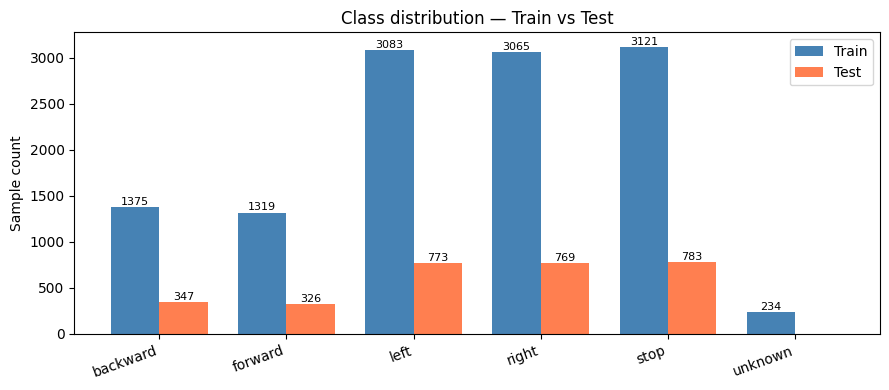

In [6]:
# ── Bar chart of class counts ──────────────────────────────────────────────────
train_counts = [np.sum(y_train_full == i) for i in range(len(CLASSES))]
test_counts  = [np.sum(y_test       == i) for i in range(len(CLASSES))]

x = np.arange(len(CLASSES))
w = 0.38
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x - w/2, train_counts, width=w, label='Train', color='steelblue')
ax.bar(x + w/2, test_counts,  width=w, label='Test',  color='coral')
ax.set_xticks(x)
ax.set_xticklabels(CLASSES, rotation=20, ha='right')
ax.set_ylabel('Sample count')
ax.set_title('Class distribution — Train vs Test')
ax.legend()
for bar in ax.patches:
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width()/2, h + 1, str(int(h)),
                ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

### 2b. Feature statistics (per-feature mean and std)

Feature value summary (across all train samples):
  Global mean:  0.0268
  Global std:   0.8912
  Global min:   -8.6465
  Global max:   7.3728


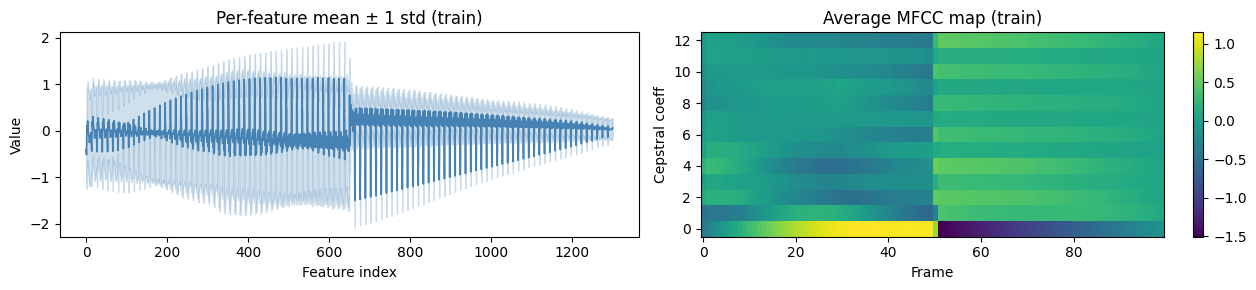

In [7]:
feat_mean = X_train_full.mean(axis=0)
feat_std  = X_train_full.std(axis=0)

print('Feature value summary (across all train samples):')
print(f'  Global mean:  {X_train_full.mean():.4f}')
print(f'  Global std:   {X_train_full.std():.4f}')
print(f'  Global min:   {X_train_full.min():.4f}')
print(f'  Global max:   {X_train_full.max():.4f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 3))
axes[0].plot(feat_mean, lw=1.2, color='steelblue')
axes[0].fill_between(range(FEATURE_LEN),
                     feat_mean - feat_std, feat_mean + feat_std,
                     alpha=0.25, color='steelblue')
axes[0].set_title('Per-feature mean ± 1 std (train)')
axes[0].set_xlabel('Feature index'); axes[0].set_ylabel('Value')

# Reshape to (N, frames, cepstral) and average across samples to visualise MFCC map
mean_mfcc = X_train_full.reshape(-1, N_FRAMES, N_CEPSTRAL).mean(axis=0).T
im = axes[1].imshow(mean_mfcc, aspect='auto', origin='lower', cmap='viridis')
plt.colorbar(im, ax=axes[1])
axes[1].set_title('Average MFCC map (train)')
axes[1].set_xlabel('Frame'); axes[1].set_ylabel('Cepstral coeff')
plt.tight_layout()
plt.show()

### 2c. Sample MFCC maps — one per class

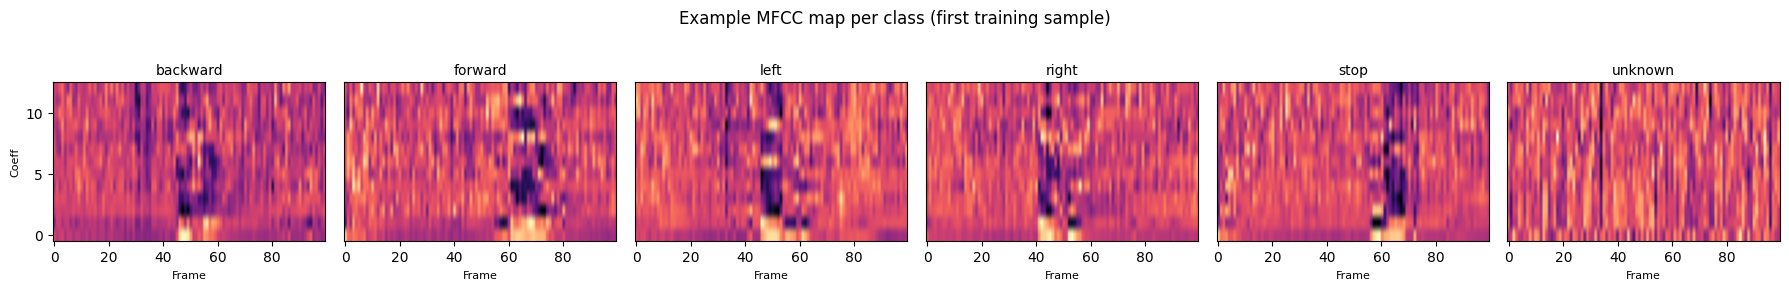

In [8]:
fig, axes = plt.subplots(1, len(CLASSES), figsize=(3 * len(CLASSES), 2.8))
for i, (ax, cls) in enumerate(zip(axes, CLASSES)):
    idx = np.where(y_train_full == i)[0]
    if len(idx) == 0:
        ax.set_visible(False)
        continue
    sample = X_train_full[idx[0]].reshape(N_FRAMES, N_CEPSTRAL).T
    ax.imshow(sample, aspect='auto', origin='lower', cmap='magma')
    ax.set_title(cls, fontsize=10)
    ax.set_xlabel('Frame', fontsize=8)
    if i == 0:
        ax.set_ylabel('Coeff', fontsize=8)
    else:
        ax.set_yticks([])
plt.suptitle('Example MFCC map per class (first training sample)', y=1.02)
plt.tight_layout()
plt.show()

### 2d. Feature value histogram

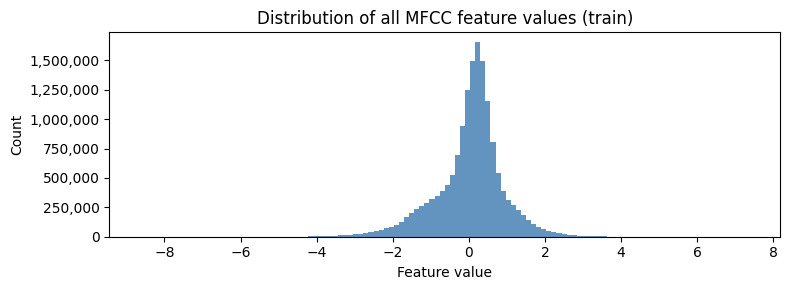

In [9]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(X_train_full.ravel(), bins=120, color='steelblue', edgecolor='none', alpha=0.85)
ax.set_title('Distribution of all MFCC feature values (train)')
ax.set_xlabel('Feature value')
ax.set_ylabel('Count')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

### 2e. Per-class feature mean heatmap

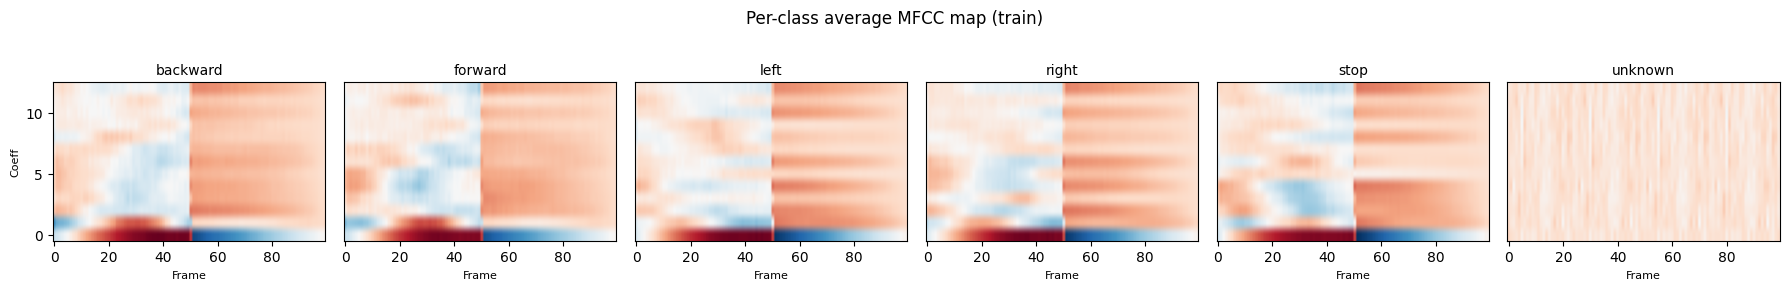

In [10]:
class_means = np.stack([
    X_train_full[y_train_full == i].mean(axis=0)
    for i in range(len(CLASSES))
])  # (n_classes, FEATURE_LEN)

# Visualise as MFCC map per class
fig, axes = plt.subplots(1, len(CLASSES), figsize=(3 * len(CLASSES), 2.8))
vmin, vmax = class_means.min(), class_means.max()
for i, (ax, cls) in enumerate(zip(axes, CLASSES)):
    map_2d = class_means[i].reshape(N_FRAMES, N_CEPSTRAL).T
    ax.imshow(map_2d, aspect='auto', origin='lower', cmap='RdBu_r',
              vmin=vmin, vmax=vmax)
    ax.set_title(cls, fontsize=10)
    ax.set_xlabel('Frame', fontsize=8)
    if i == 0:
        ax.set_ylabel('Coeff', fontsize=8)
    else:
        ax.set_yticks([])
plt.suptitle('Per-class average MFCC map (train)', y=1.02)
plt.tight_layout()
plt.show()

## 3. Train / val split + normalisation

EI already gives us a train/test split; we carve validation out of train only.

In [11]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=VAL_FRAC,
    stratify=y_train_full,
    random_state=0,
)

# No normalisation — EI's MFCC DSP block already scales features appropriately.
# Z-score normalisation on top of EI output can hurt accuracy.
X_train_n = X_train
X_val_n   = X_val
X_test_n  = X_test

y_train_oh = tf.keras.utils.to_categorical(y_train, len(CLASSES))
y_val_oh   = tf.keras.utils.to_categorical(y_val,   len(CLASSES))
y_test_oh  = tf.keras.utils.to_categorical(y_test,  len(CLASSES))

print(f'Train : {X_train_n.shape}  Val : {X_val_n.shape}  Test : {X_test_n.shape}')


Train : (10367, 1300)  Val : (1830, 1300)  Test : (2998, 1300)


## 4. Load EI-trained model (`model.h5`)

Drop `model.h5` (exported from **EI Studio → Dashboard → Download model → Keras (.h5)**)
into the same folder as this notebook, then run this cell.

Loading EI's own trained weights means the model has always seen EI-internal feature scaling,
so there is no train/deploy mismatch when the `.tflite` is imported back into EI.


In [12]:
model = tf.keras.models.load_model(EI_MODEL_PATH, compile=False)
model.summary()

# Sanity check: input shape must match our feature length
expected_input = (None, FEATURE_LEN)
actual_input   = tuple(model.input_shape)
assert actual_input == expected_input, (
    f'Model input shape {actual_input} does not match FEATURE_LEN={FEATURE_LEN}. '
    'Check N_FRAMES / N_CEPSTRAL in Config.')

# Quick accuracy check on test set before we do anything else
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
_, baseline_acc = model.evaluate(X_test_n, y_test_oh, verbose=0)
print(f'EI baseline accuracy on .npy test set: {baseline_acc*100:.2f}%')


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 reshape (Reshape)           (None, 100, 13)           0         
                                                                 
 conv1d (Conv1D)             (None, 100, 8)            320       
                                                                 
 max_pooling1d (MaxPooling1  (None, 50, 8)             0         
 D)                                                              
                                                                 
 dropout (Dropout)           (None, 50, 8)             0         
                                                                 
 conv1d_1 (Conv1D)           (None, 50, 16)            400       
                                                                 
 max_pooling1d_1 (MaxPoolin  (None, 25, 16)            0         
 g1D)                                                   

## Baseline confusion matrix


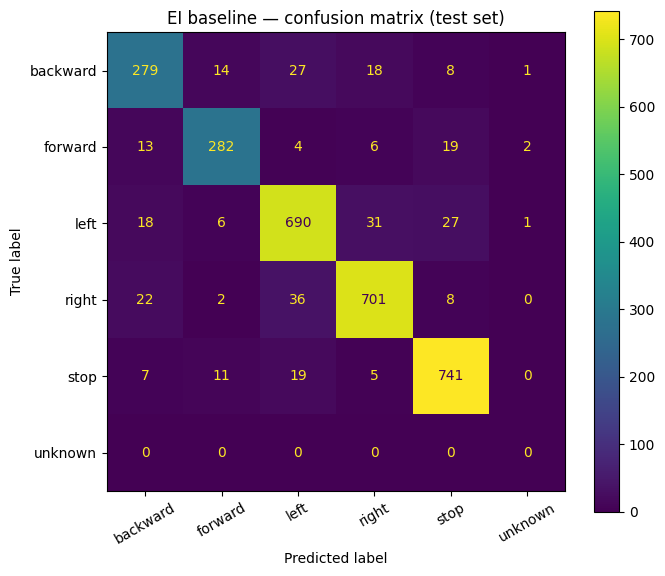

In [13]:
y_pred_prob = model.predict(X_test_n, verbose=0)
y_pred      = np.argmax(y_pred_prob, axis=1)

cm = confusion_matrix(y_test, y_pred, labels=range(len(CLASSES)))
fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES)
disp.plot(ax=ax, colorbar=True, xticks_rotation=30)
ax.set_title('EI baseline — confusion matrix (test set)')
plt.tight_layout()
plt.show()


## 5. Convert baseline to float TFLite (size reference)

In [14]:
def keras_to_tflite_float(km, out_path):
    conv = tf.lite.TFLiteConverter.from_keras_model(km)
    blob = conv.convert()
    with open(out_path, 'wb') as f:
        f.write(blob)
    return len(blob)

sz = keras_to_tflite_float(model, BASELINE_TFLITE)
print(f'Baseline float tflite: {sz} bytes ({sz/1024:.1f} KB)')

INFO:tensorflow:Assets written to: /var/folders/wt/0j3w1fqn0g7925lwmgq8mfp40000gn/T/tmprioc9uty/assets


INFO:tensorflow:Assets written to: /var/folders/wt/0j3w1fqn0g7925lwmgq8mfp40000gn/T/tmprioc9uty/assets


Baseline float tflite: 18560 bytes (18.1 KB)


2026-06-09 12:43:10.012115: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-06-09 12:43:10.012125: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-06-09 12:43:10.012282: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/wt/0j3w1fqn0g7925lwmgq8mfp40000gn/T/tmprioc9uty
2026-06-09 12:43:10.012758: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-06-09 12:43:10.012762: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/wt/0j3w1fqn0g7925lwmgq8mfp40000gn/T/tmprioc9uty
2026-06-09 12:43:10.013614: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:382] MLIR V1 optimization pass is not enabled
2026-06-09 12:43:10.013911: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-06-09 12:43:10.022947: I tensorflow/cc/saved_model/loader.

## 6. Pruning (magnitude-based, polynomial decay)

Wraps the trained model with `prune_low_magnitude`, fine-tunes for `PRUNE_EPOCHS` while
sparsity ramps 0 → `FINAL_SPARSITY`, then strips the wrappers to recover a plain Keras model
with many weights set exactly to zero.

In [15]:
num_train_steps = (len(X_train_n) // BATCH_SIZE) * PRUNE_EPOCHS

pruning_schedule = tfmot.sparsity.keras.PolynomialDecay(
    initial_sparsity=0.0,
    final_sparsity=FINAL_SPARSITY,
    begin_step=0,
    end_step=num_train_steps,
)

pruned = tfmot.sparsity.keras.prune_low_magnitude(model, pruning_schedule=pruning_schedule)
pruned.compile(
    optimizer=tf.keras.optimizers.Adam(LEARNING_RATE / 2),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

pruned.fit(
    X_train_n, y_train_oh,
    validation_data=(X_val_n, y_val_oh),
    epochs=PRUNE_EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[tfmot.sparsity.keras.UpdatePruningStep()],
    verbose=2,
)

stripped = tfmot.sparsity.keras.strip_pruning(pruned)

# Verify achieved sparsity on weight matrices (ignore bias vectors)
total, zeros = 0, 0
for w in stripped.trainable_weights:
    arr = w.numpy()
    if arr.ndim >= 2:
        total += arr.size
        zeros += int(np.sum(arr == 0))
print(f'Achieved sparsity on weight matrices: {zeros}/{total} = {100*zeros/total:.1f}%')

stripped.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
_, pruned_acc = stripped.evaluate(X_test_n, y_test_oh, verbose=0)
print(f'Pruned float32 test accuracy: {pruned_acc*100:.2f}%')

sz = keras_to_tflite_float(stripped, PRUNED_TFLITE)
print(f'Pruned float tflite: {sz} bytes ({sz/1024:.1f} KB)')

Epoch 1/15
324/324 - 1s - loss: 0.9738 - accuracy: 0.7496 - val_loss: 0.2507 - val_accuracy: 0.9049 - 1s/epoch - 4ms/step
Epoch 2/15
324/324 - 0s - loss: 0.7640 - accuracy: 0.7727 - val_loss: 0.2952 - val_accuracy: 0.8918 - 382ms/epoch - 1ms/step
Epoch 3/15
324/324 - 0s - loss: 0.6636 - accuracy: 0.7804 - val_loss: 0.3133 - val_accuracy: 0.8967 - 375ms/epoch - 1ms/step
Epoch 4/15
324/324 - 0s - loss: 0.6289 - accuracy: 0.7838 - val_loss: 0.3336 - val_accuracy: 0.8923 - 375ms/epoch - 1ms/step
Epoch 5/15
324/324 - 0s - loss: 0.5899 - accuracy: 0.7931 - val_loss: 0.3508 - val_accuracy: 0.8820 - 379ms/epoch - 1ms/step
Epoch 6/15
324/324 - 0s - loss: 0.5641 - accuracy: 0.8006 - val_loss: 0.3706 - val_accuracy: 0.8896 - 376ms/epoch - 1ms/step
Epoch 7/15
324/324 - 0s - loss: 0.5670 - accuracy: 0.7970 - val_loss: 0.3640 - val_accuracy: 0.8913 - 373ms/epoch - 1ms/step
Epoch 8/15
324/324 - 0s - loss: 0.5622 - accuracy: 0.7970 - val_loss: 0.3738 - val_accuracy: 0.8918 - 373ms/epoch - 1ms/step
Epo

INFO:tensorflow:Assets written to: /var/folders/wt/0j3w1fqn0g7925lwmgq8mfp40000gn/T/tmpdgtotdzv/assets


Pruned float tflite: 18560 bytes (18.1 KB)


2026-06-09 12:43:17.170297: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-06-09 12:43:17.170310: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-06-09 12:43:17.170403: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/wt/0j3w1fqn0g7925lwmgq8mfp40000gn/T/tmpdgtotdzv
2026-06-09 12:43:17.170866: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-06-09 12:43:17.170870: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/wt/0j3w1fqn0g7925lwmgq8mfp40000gn/T/tmpdgtotdzv
2026-06-09 12:43:17.171887: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-06-09 12:43:17.180667: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /var/folders/wt/0j3w1fqn0g7925lwmgq8mfp40000gn/T/tmpdgtotdzv
2026-06-

## 7. Post-training int8 quantisation

Uses a representative dataset (random sample from **normalised** train features) so the
converter can estimate activation ranges.  Both input and output dtypes are forced to `int8`
for the most efficient TFLite Micro kernels on Cortex-M4.

In [16]:
rep_idx  = np.random.choice(len(X_train_n), size=min(REP_DATASET_N, len(X_train_n)), replace=False)
rep_data = X_train_n[rep_idx].astype(np.float32)

def representative_dataset_gen():
    for i in range(len(rep_data)):
        yield [rep_data[i:i+1]]

converter = tf.lite.TFLiteConverter.from_keras_model(stripped)
converter.optimizations             = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset    = representative_dataset_gen
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type      = tf.int8
converter.inference_output_type     = tf.int8

int8_blob = converter.convert()
with open(INT8_TFLITE, 'wb') as f:
    f.write(int8_blob)
print(f'Int8 tflite: {len(int8_blob)} bytes ({len(int8_blob)/1024:.1f} KB)')

INFO:tensorflow:Assets written to: /var/folders/wt/0j3w1fqn0g7925lwmgq8mfp40000gn/T/tmpifduzb_u/assets


INFO:tensorflow:Assets written to: /var/folders/wt/0j3w1fqn0g7925lwmgq8mfp40000gn/T/tmpifduzb_u/assets


Int8 tflite: 10560 bytes (10.3 KB)


/Users/nick/College Schoolwork Local/SP26/EE446/tinyml-arduino/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-06-09 12:43:17.562712: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-06-09 12:43:17.562722: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-06-09 12:43:17.562816: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/wt/0j3w1fqn0g7925lwmgq8mfp40000gn/T/tmpifduzb_u
2026-06-09 12:43:17.563274: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-06-09 12:43:17.563278: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/wt/0j3w1fqn0g7925lwmgq8mfp40000gn/T/tmpifduzb_u
2026-06-09 12:43:17.564265: I tensorflow/cc/saved_

## 8. Evaluate all three models on the test set

In [17]:
import time
def run_tflite_eval(tflite_path, X, y, return_preds=False):
    interp = tf.lite.Interpreter(tflite_path)
    interp.allocate_tensors()
    inp = interp.get_input_details()[0]
    out = interp.get_output_details()[0]
    correct = 0
    preds   = []
    for i in range(len(X)):
        x = X[i:i+1].astype(np.float32)
        if inp['dtype'] == np.int8:
            scale, zp = inp['quantization']
            x = (x / scale + zp).astype(np.int8)
        interp.set_tensor(inp['index'], x)
        interp.invoke()
        o = interp.get_tensor(out['index'])[0]
        if out['dtype'] == np.int8:
            scale, zp = out['quantization']
            o = (o.astype(np.float32) - zp) * scale
        p = int(np.argmax(o))
        preds.append(p)
        if p == y[i]:
            correct += 1
    acc = correct / len(X)
    if return_preds:
        return acc, np.array(preds)
    return acc
print(f"{'Model':<18} {'Accuracy':>9}  {'Size (B)':>10}  {'Size (KB)':>10}  {'Latency':>10}")
print('-' * 75)
results = {}
for label, path in [('baseline float', BASELINE_TFLITE),
                    ('pruned float',   PRUNED_TFLITE),
                    ('pruned int8',    INT8_TFLITE)]:
    start = time.perf_counter()
    acc, preds = run_tflite_eval(path, X_test_n, y_test, return_preds=True)
    end = time.perf_counter()
    elapsed_time = end - start
    sz = os.path.getsize(path)
    results[label] = (acc, sz, preds, elapsed_time)
    print(f'{label:<18} {acc*100:>8.2f}%  {sz:>10,}  {sz/1024:>9.1f}  {elapsed_time}')

Model               Accuracy    Size (B)   Size (KB)     Latency
---------------------------------------------------------------------------


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


baseline float        89.83%      18,560       18.1  0.03683662499952334
pruned float          88.63%      18,560       18.1  0.03593270799956372
pruned int8           88.63%      10,560       10.3  0.04009608300020773


### Confusion matrix — pruned int8 model

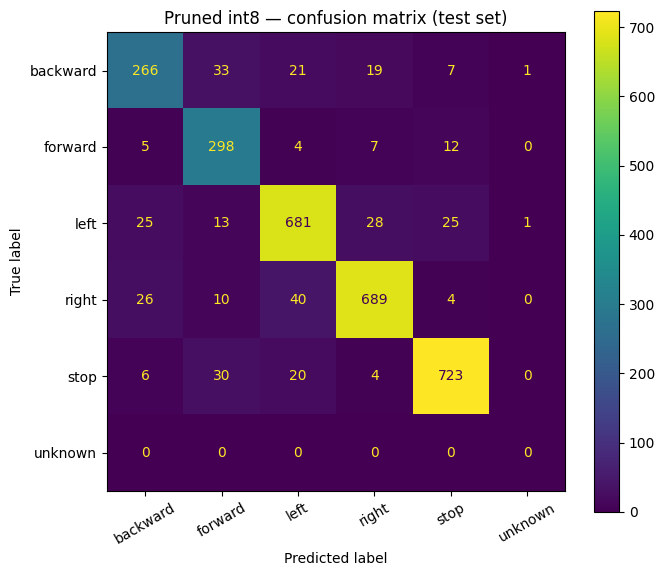

In [19]:
_, _, int8_preds, *_ = results['pruned int8']
cm_int8 = confusion_matrix(y_test, int8_preds, labels=range(len(CLASSES)))

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_int8, display_labels=CLASSES)
disp.plot(ax=ax, colorbar=True, xticks_rotation=30)
ax.set_title('Pruned int8 — confusion matrix (test set)')
plt.tight_layout()
plt.show()

### Accuracy / size trade-off bar chart

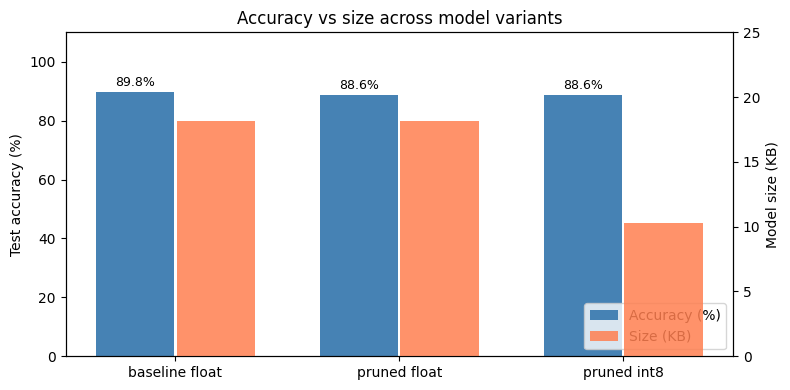

In [20]:
labels = list(results.keys())
accs   = [results[l][0] * 100 for l in labels]
sizes  = [results[l][1] / 1024 for l in labels]

x = np.arange(len(labels))
fig, ax1 = plt.subplots(figsize=(8, 4))
ax2 = ax1.twinx()
bars = ax1.bar(x - 0.18, accs, width=0.35, color='steelblue', label='Accuracy (%)')
ax2.bar(x + 0.18, sizes, width=0.35, color='coral', alpha=0.85, label='Size (KB)')
ax1.set_ylabel('Test accuracy (%)')
ax2.set_ylabel('Model size (KB)')
ax1.set_xticks(x)
ax1.set_xticklabels(labels)
ax1.set_ylim(0, 110)
ax2.set_ylim(0,25)
ax1.set_title('Accuracy vs size across model variants')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower right')
for bar, v in zip(bars, accs):
    ax1.text(bar.get_x() + bar.get_width()/2, v + 1, f'{v:.1f}%',
             ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()